# 04 — Multi-asset portfolios: momentum, low volatility, and risk parity

A single-asset strategy asks, “Should I hold this asset?” A portfolio strategy asks two questions: “Which assets should I hold?” and “How much of each should I hold?” This notebook answers those questions with simple monthly-rebalanced ETF portfolios.

> Educational research only. This notebook is not investment advice.

## Beginner guide: cross-sectional versus time-series signals

The time-series momentum notebook looked at one asset and asked whether its own past return was positive. **Cross-sectional momentum** instead ranks several assets against one another: buy the recent winners in the universe. The strategy can hold a winner even when the whole market is weak, so its benchmark and risk behavior can differ from a trend filter on SPY.

Volatility is a measure of how much returns move around. **Low-volatility selection** chooses the assets with the smallest recent volatility. **Inverse-volatility weighting** gives smaller weights to more volatile assets and larger weights to calmer assets. It is a simple risk-parity approximation: exact equal risk contribution also depends on correlations, but inverse volatility is transparent enough to learn first.

All portfolio decisions are made at the start of each month using data available before that rebalance. The backtester then delays the weights by one day before applying returns.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    cross_sectional_momentum_weights,
    equal_weight_weights,
    inverse_volatility_weights,
    low_volatility_weights,
    run_portfolio_backtest,
)
from src.backtest import split_time_series
from src.research import comparison_table, metrics_for_period

## Data and assumptions

The universe is a fixed set of liquid, broad ETFs: SPY (US large-cap stocks), QQQ (Nasdaq-100), IWM (US small-cap stocks), EFA (developed international stocks), EEM (emerging-market stocks), TLT (long-term US Treasury bonds), and GLD (gold). This is an educational universe, not a claim that these are the only or best assets to use.

We use adjusted daily closes from Yahoo Finance, monthly rebalancing, 10 bps per unit of turnover, and an untouched final 20% test period. The equal-weight portfolio is the internal control; SPY remains the market benchmark.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD']

if USE_DEMO_DATA:
    close = pd.concat(
        [make_demo_ohlcv(periods=2_000, seed=i + 1)['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
        axis=1,
    )
else:
    try:
        close = load_price_panel(TICKERS, '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat(
            [make_demo_ohlcv(periods=2_000, seed=i + 1)['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
            axis=1,
        )

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2010-01-04 through 2025-12-31 (4,024 common trading days)
{'train': (datetime.date(2010, 1, 4), datetime.date(2019, 8, 6), 2414), 'validation': (datetime.date(2019, 8, 7), datetime.date(2022, 10, 14), 805), 'test': (datetime.date(2022, 10, 17), datetime.date(2025, 12, 31), 805)}


## Research ideas and sources

- **Cross-sectional momentum:** [Jegadeesh and Titman’s 1993 paper](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x) studies buying past winners and selling past losers over intermediate holding periods. Here we use a long-only top-three ETF adaptation, so this is a teaching experiment rather than an exact paper replication.
- **Low volatility:** [AQR’s defensive-equity overview](https://www.aqr.com/Insights/Research/White-Papers/Understanding-Defensive-Equity) describes the low-risk anomaly and its relationship to lower-volatility portfolios. This notebook selects the three lowest-volatility ETFs in the declared universe.
- **Risk parity:** [Edward Qian’s risk-parity paper](https://docslib.org/doc/3622281/risk-parity-portfolios-chief-investment-officer-and-head-of-research-macro-strategies-efficient-portfolios-through-true-diversification) motivates thinking about portfolio risk contributions rather than allocating only by dollars. We use inverse trailing volatility as a deliberately simple approximation.

A portfolio can look diversified by ticker but still be concentrated in one risk source. For example, several equity ETFs may fall together. That is why we report drawdown and volatility, not just the number of holdings.

In [3]:
weights = {
    'Equal-weight control': equal_weight_weights(close),
    'Cross-sectional momentum': cross_sectional_momentum_weights(close, lookback=126, top_n=3),
    'Low-volatility selection': low_volatility_weights(close, lookback=60, top_n=3),
    'Inverse-volatility risk parity': inverse_volatility_weights(close, lookback=60),
}

results = {
    name: run_portfolio_backtest(
        close,
        target_weights,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        benchmark_returns=benchmark_returns,
    )
    for name, target_weights in weights.items()
}
print('Portfolio results are ready. The next table uses only the untouched test period.')

Portfolio results are ready. The next table uses only the untouched test period.


## Test-period comparison

The benchmark-relative column answers a narrow question: did the portfolio beat SPY over this specific test interval after the simple cost model? It does not tell us what will happen next. Compare return with drawdown and turnover together. A portfolio with a lower return and much lower drawdown may be useful for a different objective, but the backtest alone does not decide that objective for us.

In [4]:
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Equal-weight control,21.28%,12.83%,1.57,2.45,-12.76%,1.67,56.27%,0.00,0,85.23%,99.27%,-14.04%
Cross-sectional momentum,20.61%,14.33%,1.38,2.10,-13.50%,1.53,55.90%,5.01,23,81.95%,99.27%,-17.33%
Low-volatility selection,22.73%,11.22%,1.88,2.96,-8.42%,2.70,55.90%,3.97,18,92.35%,99.27%,-6.92%
Inverse-volatility risk parity,20.91%,12.21%,1.62,2.53,-11.55%,1.81,55.78%,0.89,38,83.41%,99.27%,-15.86%


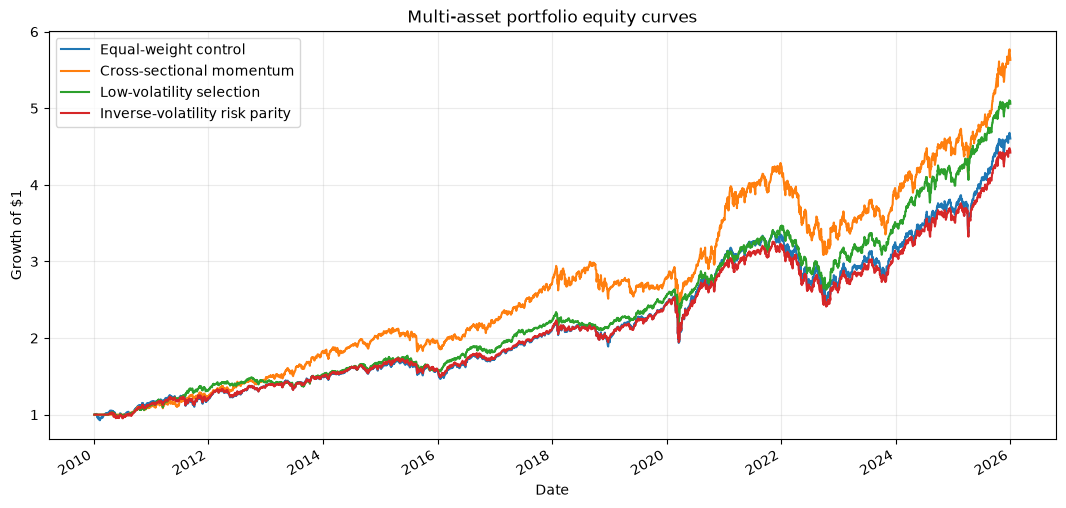

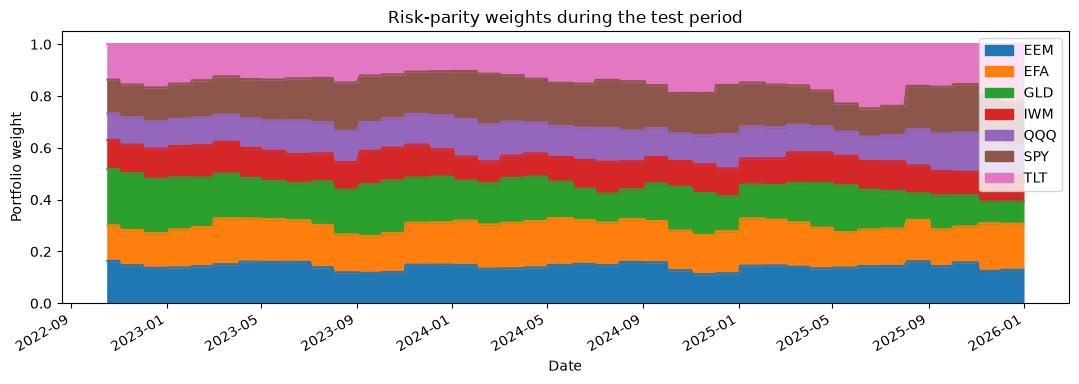

In [5]:
ax = None
for name, result in results.items():
    normalized_equity = result.frame['equity'] / result.frame['equity'].iloc[0]
    ax = normalized_equity.plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Multi-asset portfolio equity curves')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

results['Inverse-volatility risk parity'].held_weights.loc[splits['test'].index].plot.area(figsize=(13, 4), title='Risk-parity weights during the test period')
plt.ylabel('Portfolio weight')
plt.show()

## Cost sensitivity

Monthly rebalancing is less frequent than daily trading, but changing several ETF weights can still create meaningful turnover. The cost table tests whether a conclusion survives a range of one-way cost assumptions.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    for name, target_weights in weights.items():
        cost_result = run_portfolio_backtest(
            close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns
        )
        m = metrics_for_period(cost_result, splits['test'].index)
        cost_rows.append({
            'strategy': name,
            'cost_bps': cost_bps,
            'test_return': m['total_return_after_costs'],
            'test_sharpe': m['sharpe_ratio'],
            'annualized_turnover': m['annualized_turnover'],
        })

pd.DataFrame(cost_rows).style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'annualized_turnover': '{:.2f}',
})

,strategy,cost_bps,test_return,test_sharpe,annualized_turnover
0,Equal-weight control,0,85.23%,1.57,0.00
1,Cross-sectional momentum,0,84.89%,1.42,5.01
2,Low-volatility selection,0,94.81%,1.92,3.97
3,Inverse-volatility risk parity,0,83.93%,1.62,0.89
4,Equal-weight control,5,85.23%,1.57,0.00
5,Cross-sectional momentum,5,83.41%,1.40,5.01
6,Low-volatility selection,5,93.58%,1.90,3.97
7,Inverse-volatility risk parity,5,83.67%,1.62,0.89
8,Equal-weight control,10,85.23%,1.57,0.00
9,Cross-sectional momentum,10,81.95%,1.38,5.01


## A small robustness sweep

We now vary only a few declared choices. The validation period ranks the candidates; the test period is shown afterward. This is a teaching example of the workflow, not proof that the best validation candidate is genuinely superior. If rankings change dramatically between validation and test, the strategy family is unstable on this sample.

In [7]:
candidate_builders = {
    'Cross-sectional momentum': lambda lookback, top_n: cross_sectional_momentum_weights(close, lookback=lookback, top_n=top_n),
    'Low-volatility selection': lambda lookback, top_n: low_volatility_weights(close, lookback=lookback, top_n=top_n),
    'Inverse-volatility risk parity': lambda lookback, top_n: inverse_volatility_weights(close, lookback=lookback),
}
candidate_grid = {
    'Cross-sectional momentum': [(63, 2), (126, 3), (252, 3)],
    'Low-volatility selection': [(40, 2), (60, 3), (120, 3)],
    'Inverse-volatility risk parity': [(40, 1), (60, 1), (120, 1)],
}

rows = []
for family, candidates in candidate_grid.items():
    for lookback, top_n in candidates:
        candidate_weights = candidate_builders[family](lookback, top_n)
        candidate_result = run_portfolio_backtest(
            close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
        )
        validation = metrics_for_period(candidate_result, splits['validation'].index)
        test = metrics_for_period(candidate_result, splits['test'].index)
        rows.append({
            'family': family,
            'lookback': lookback,
            'top_n': top_n,
            'validation_sharpe': validation['sharpe_ratio'],
            'test_sharpe': test['sharpe_ratio'],
            'test_return': test['total_return_after_costs'],
            'test_max_drawdown': test['max_drawdown'],
        })

portfolio_sweep = pd.DataFrame(rows)
portfolio_sweep.style.format({
    'validation_sharpe': '{:.2f}',
    'test_sharpe': '{:.2f}',
    'test_return': '{:.2%}',
    'test_max_drawdown': '{:.2%}',
})

,family,lookback,top_n,validation_sharpe,test_sharpe,test_return,test_max_drawdown
0,Cross-sectional momentum,63,2,0.27,1.09,65.54%,-12.76%
1,Cross-sectional momentum,126,3,0.38,1.38,81.95%,-13.50%
2,Cross-sectional momentum,252,3,0.28,1.57,93.43%,-13.91%
3,Low-volatility selection,40,2,-0.02,1.73,86.83%,-10.02%
4,Low-volatility selection,60,3,0.36,1.88,92.35%,-8.42%
5,Low-volatility selection,120,3,-0.16,1.52,73.61%,-11.27%
6,Inverse-volatility risk parity,40,1,0.26,1.63,84.02%,-11.36%
7,Inverse-volatility risk parity,60,1,0.25,1.62,83.41%,-11.55%
8,Inverse-volatility risk parity,120,1,0.22,1.60,82.78%,-11.92%


## Conclusion checklist

Before adding more complexity, answer these questions in your own words:

- Did selection improve the benchmark-relative result, or did it mainly change the drawdown path?
- Did momentum and low volatility select the same assets, or are they genuinely different signals?
- Did the validation winner remain competitive in the test period?
- How much turnover did each portfolio require, and how did that affect cost sensitivity?
- What important risks are missing from this simplified study? Examples include ETF liquidity, bid-ask spreads, taxes, asset delistings, data revisions, and correlations changing during stress.

The honest outcome may be that the equal-weight control or SPY is hard to beat. That is a valuable benchmark result, not a reason to hide the experiment.

## What went well / what went wrong

**What went well:** Cross-asset selection adds diversification across equities, bonds, and gold. In the current live run, low-volatility selection improved risk-adjusted performance and drawdown relative to the equal-weight control.

**What went wrong:** The universe is only seven ETFs, so it is not the same as a broad institutional portfolio. Assets can become correlated during stress, a strategy can lag SPY while reducing risk, and monthly reallocation still creates turnover. Results are sensitive to the chosen universe and start date.

The key question is whether the lower drawdown or different risk exposure justifies any return shortfall after realistic costs.